# Imports

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from lib.utils import load_graph_data  # If needed for adjacency matrix
import yaml
import os
import shutil

from lib.utils import load_graph_data
from model.pytorch.dcrnn_supervisor import DCRNNSupervisor

from scripts.delete_models import delete

2025-03-14 16:53:43.674763: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-14 16:53:43.676059: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-14 16:53:43.701131: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-14 16:53:43.701727: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-14 16:53:44.102632: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

# Load and Predict

In [2]:
def run_dcrnn(config_filename, input_filename, output_filename):
    with open(config_filename) as f:
        supervisor_config = yaml.load(f, Loader=yaml.FullLoader)
        # supervisor_config["train"]["epochs"] = 1

        graph_pkl_filename = supervisor_config['data'].get('graph_pkl_filename')
        sensor_ids, sensor_id_to_ind, adj_mx = load_graph_data(graph_pkl_filename)

        supervisor = DCRNNSupervisor(adj_mx=adj_mx, **supervisor_config)
        # supervisor.train()
        # supervisor.dcrnn_model.forward()
        supervisor.load_model2(input_filename)

        # checkpoint_path = 'models/epo92.tar'  # Adjust the filename as needed
        # checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

        # supervisor.dcrnn_model.load_state_dict(checkpoint['model_state_dict'])

        for dataset in ["train","val","test"]:
            mean_score, outputs = supervisor.evaluate(dataset)
            output_filename2 = "data/predictions/" + dataset + "_" + output_filename
            np.savez_compressed(output_filename2, **outputs)
            print("{} MAE : {}".format(dataset, mean_score))
            print('{} Predictions saved as {}.'.format(dataset, output_filename2))

In [3]:
config = "config.yaml"
input_name = "models/epo59.tar"
output_name = "dcrnn_predictions.npz"

run_dcrnn(config_filename=config,
          input_filename=input_name,
          output_filename=output_name)

2025-03-14 16:53:49,279 - INFO - Log directory: experiments/dcrnn_DR_2_h_24_32-32-32_lr_0.001_bs_64_0314165349/
2025-03-14 16:53:49,578 - INFO - Model created


/home/gems/Documents/DCRNN_PyTorch/lib/utils.py:104: RuntimeWarning: divide by zero encountered in power
  d_inv = np.power(d, -1).flatten()


2025-03-14 16:53:50,525 - INFO - Loaded model at models/epo59.tar


/home/gems/Documents/DCRNN_PyTorch/model/pytorch/dcrnn_supervisor.py:101: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(addr, map_location='cpu')


train MAE : 11.177063868596004
train Predictions saved as data/predictions/train_dcrnn_predictions.npz.
val MAE : 5.880616068840027
val Predictions saved as data/predictions/val_dcrnn_predictions.npz.
test MAE : 6.011509418487549
test Predictions saved as data/predictions/test_dcrnn_predictions.npz.


# Visualization

In [11]:
def create_learning_curve(log_file):
    val_mae_values = []
    train_mae_values = []
    stop_epoch = None
    patience = 30

    # Parse log file
    with open(log_file, 'r') as f:
        for line in f:
            if 'val_mae' in line:
                val_mae = float(line.split('val_mae: ')[1].split(',')[0])
                val_mae_values.append(val_mae)
            if 'Early stopping at epoch' in line:
                stop_epoch = int(line.split('epoch: ')[1]) - patience
            if 'train_mae' in line and 'test_mae' not in line:
                train_mae = float(line.split('train_mae: ')[1].split(',')[0])
                train_mae_values.append(train_mae)

    # Create the figure and axis
    fig, ax = plt.subplots()

    # Plot
    ax.plot(train_mae_values, label="Train MAE")
    ax.plot(val_mae_values, label="Val MAE")
    if stop_epoch is not None:
        ax.axvline(x=stop_epoch, color='r', linestyle='--', label='Early stopping')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAE')
    ax.set_title('Learning Curve')
    ax.legend()
    
    # Return the figure object so we can use it elsewhere
    return fig

def save_learning_curve(fig, filename):
    # Save the figure to the specified file
    fig.savefig(filename, bbox_inches='tight')

def compute_at_horizon(predictions, truth, sample_idx, sensor_idx):
    # Extract time series
    predicted_values = predictions[sample_idx, :, sensor_idx] # (192,)
    truth_values = truth[sample_idx, :, sensor_idx] # (192,)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(truth_values, label="Ground Truth", linestyle='dashed', color='blue')
    plt.plot(predicted_values, label="Prediction", linestyle='solid', color='red')
    plt.xlabel("Time Step")
    plt.ylabel("PM2.5 Level")
    plt.title(f"Predicted vs. Ground Truth PM2.5 for Sensor {sensor_idx}")
    plt.legend()
    plt.show()


def compute_mae_per_horizon(array1, array2):
    """
    Computes the Mean Absolute Error (MAE) per horizon.
    """
    mae_horizon = np.mean(np.mean(np.abs(array1 - array2), axis=1), axis=1)

    # MAE growth over timestep
    horizons = horizons = np.arange(1, len(mae_horizon) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(horizons, mae_horizon, marker='o', linestyle='-', color='b', label="MAE")
    plt.xticks(horizons)  # Ensure x-axis shows 1-24
    plt.xlabel("Horizon (t+1)")
    plt.ylabel("Mean Absolute Error")
    plt.title("MAE per Horizon")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.ylim(0, None)
    plt.show()

def compute_at_sample(predictions, truth, sample_idx, sensor_idx):

    plt.plot(truth[:, sample_idx, sensor_idx], label="Ground Truth", marker='o')
    plt.plot(predictions[:, sample_idx, sensor_idx], label="Prediction", marker='x')

    plt.xlabel("Prediction Horizon (t+1 to t+24)")
    plt.ylabel("PM2.5 Level")
    plt.title(f"PM2.5 Prediction vs. Ground Truth for Sensor {sensor_idx}")
    plt.legend()
    plt.show()

def compute_mae_per_sample(array1, array2):
    """
    Computes the Mean Absolute Error (MAE) per sample
    """
    mae_horizon = np.mean(np.mean(np.abs(array1 - array2), axis=1), axis=0)

    # MAE growth over timestep
    horizons = horizons = np.arange(1, len(mae_horizon) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(horizons, mae_horizon, marker='o', linestyle='-', color='b', label="MAE")
    plt.xticks(horizons)  # Ensure x-axis shows 1-24
    plt.xlabel("Horizon (t+1)")
    plt.ylabel("Mean Absolute Error")
    plt.title("MAE per Sample")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.ylim(0, None)
    plt.show()

        
def visualize(file_name):

    # Load the saved predictions
    data = np.load(file_name)

    # Check what keys are available in the saved file
    print("Available keys:", data.files)

    # Access specific arrays
    for key in data.files:
        print(f"{key}: shape {data[key].shape}")

    # Extract predictions and ground truth
    predictions = data['prediction']  # (12, 192, 92)
    truth = data['truth']  # (12, 192, 92)


    compute_at_horizon(predictions,truth,0,0)
    compute_mae_per_horizon(predictions,truth)
    compute_at_sample(predictions,truth,0,0)
    compute_mae_per_sample(predictions,truth)


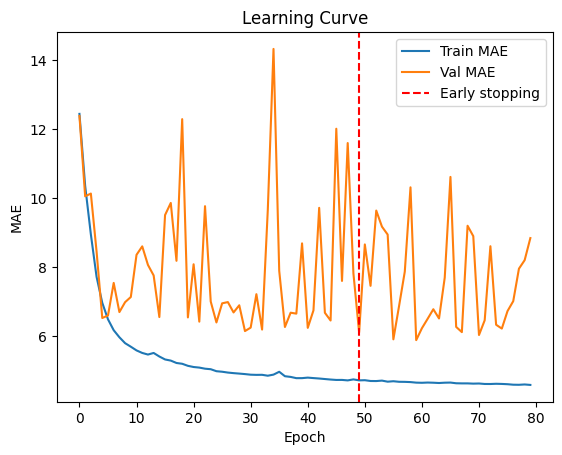

In [13]:
fig = create_learning_curve("experiments/dcrnn_DR_2_h_24_32-32-32_lr_0.001_bs_64_0314161003/info.log")

Available keys: ['prediction', 'truth']
prediction: shape (24, 832, 92)
truth: shape (24, 832, 92)


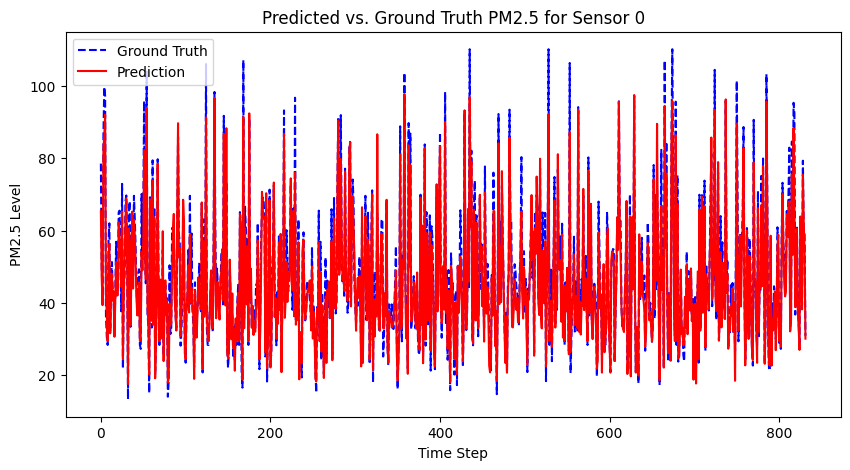

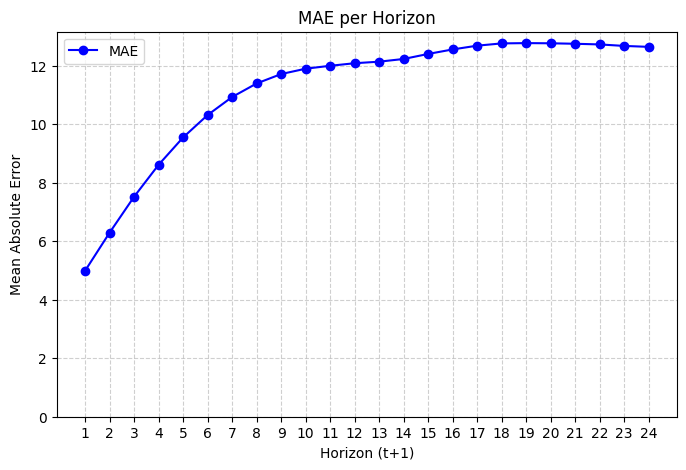

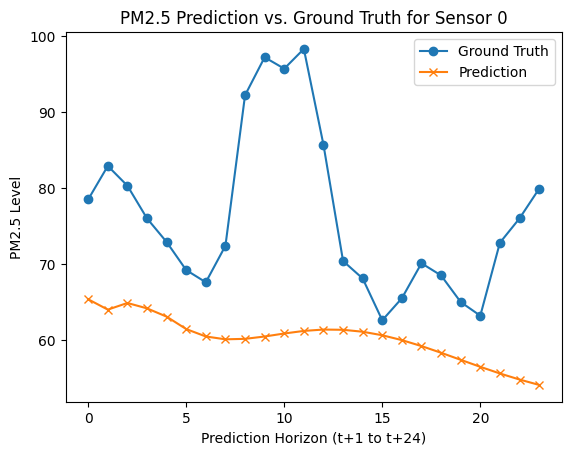

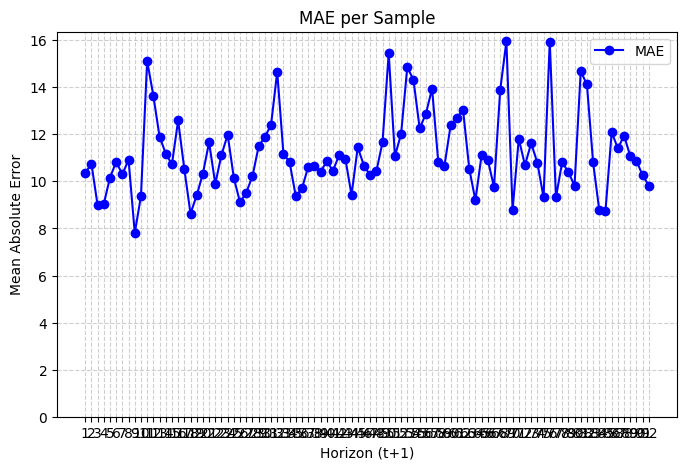

In [8]:
visualize("data/predictions/train_dcrnn_predictions.npz")

Available keys: ['prediction', 'truth']
prediction: shape (24, 256, 92)
truth: shape (24, 256, 92)


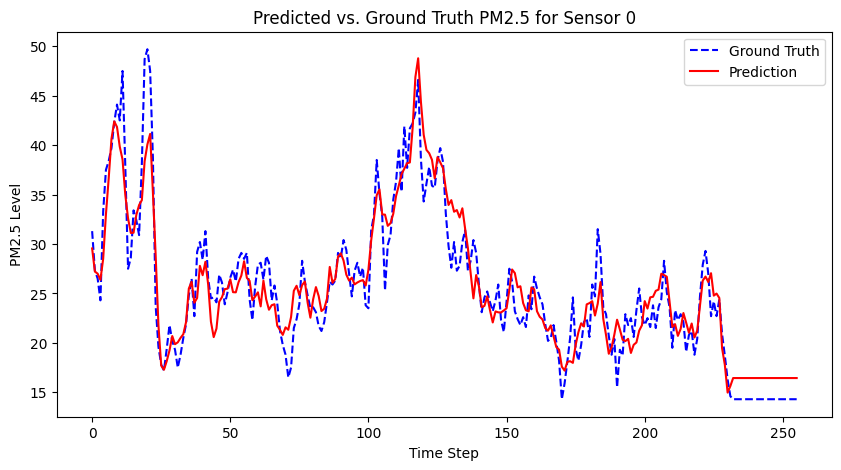

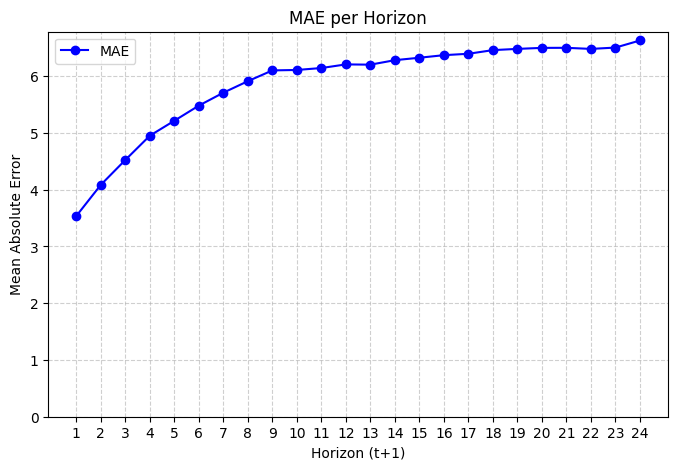

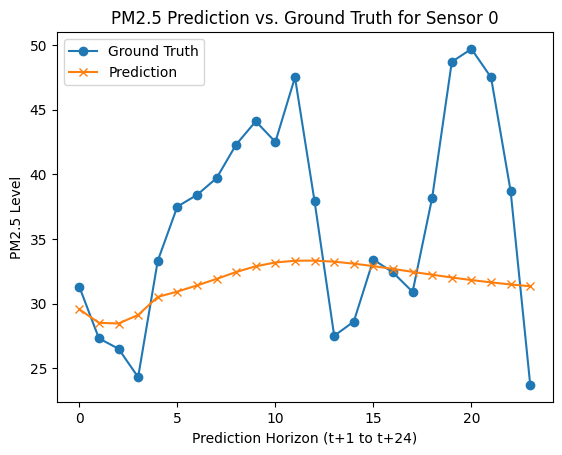

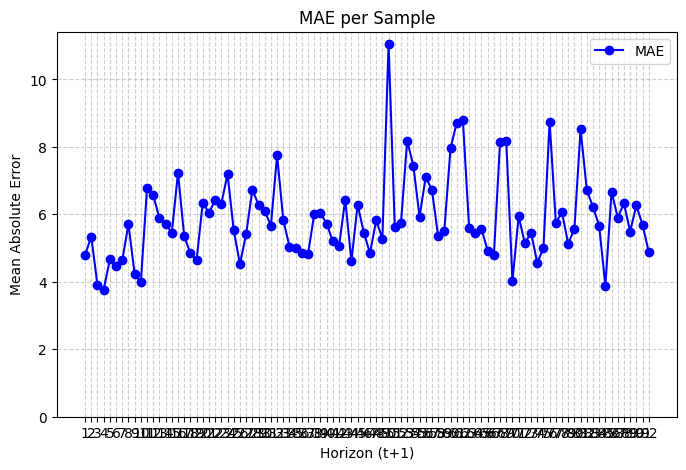

In [9]:
visualize("data/predictions/val_dcrnn_predictions.npz")

Available keys: ['prediction', 'truth']
prediction: shape (24, 128, 92)
truth: shape (24, 128, 92)


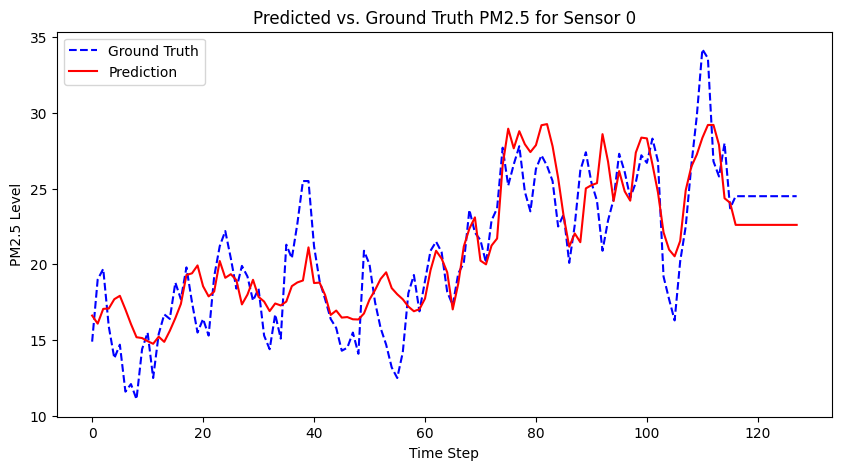

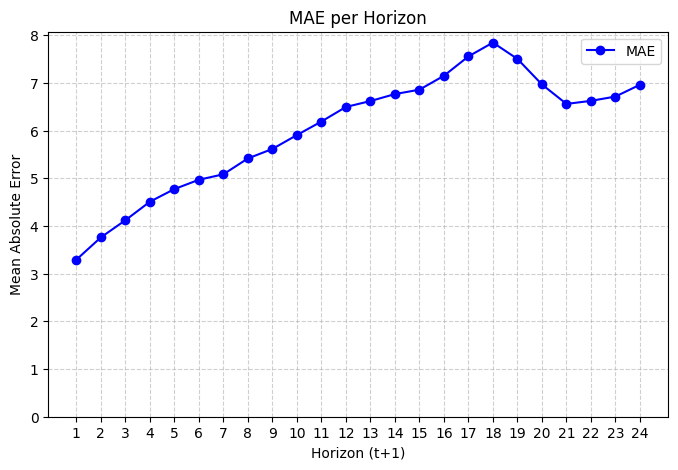

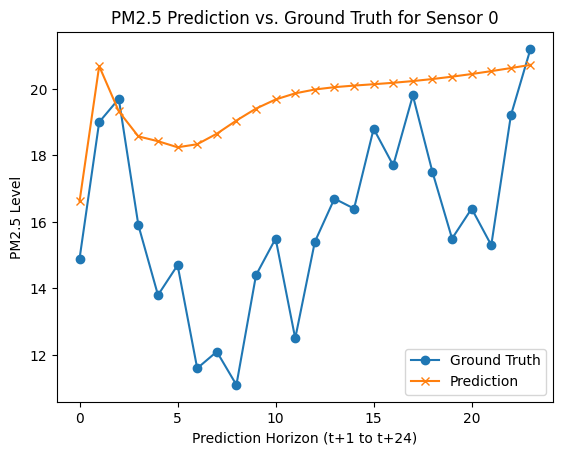

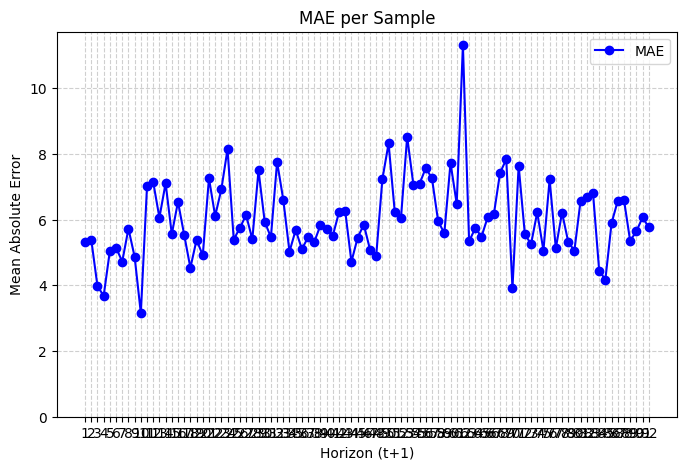

In [10]:
visualize("data/predictions/test_dcrnn_predictions.npz")

# Dimension meaning:

### Object: shape (horizon: h, num_sample: n, num_nodes: s)

- horizon: Each slice h = [0-23] correspond to the value at t+1+h tiemstep 
- num_sample: Each slice n = [0-191] correspond to the n starting position on the data
- num_nodes: Each slice s = [0-91] correspond to the 92 weather stations

### Usefully,

#### [:,i,j]: 
- gives all 24 timestep predictions where data is given to the model upto the ith timestep
- varying i shows how recursive predictions worsen over time
#### [i,:,j]: 
- gives all 192 timestep predictions where those prediction is at timestep t+1+i
- varying i shows the result at different starting points

### Expectation

- The MAE at horizon should have as little upward slope as possible with increasing timestep
- The MAE at samples should not increase much as sample goes forward as it indicates overfitting

# Save good model and Delete unnecessary models

In [14]:
def save_model(nickname,input_address,output_directory,fig):
    """Save the model along with the current config file to a folder"""
    # Create the new directory path
    new_folder = os.path.join(output_directory, nickname)
    os.makedirs(new_folder, exist_ok=True)  # Create folder if it doesn't exist

    # Copy the config.yaml file
    config_source = "config.yaml"
    if os.path.exists(config_source):
        shutil.copy(config_source, new_folder)
    else:
        print(f"Warning: {config_source} not found.")

    # Copy the input file
    if os.path.exists(input_address):
        shutil.copy(input_address, new_folder)
    else:
        print(f"Warning: {input_address} not found.")

    # Save the learning curve figure
    save_learning_curve(fig,new_folder+"/"+"fig")

    print(f"Setup complete. Files copied to {new_folder}")

In [15]:
save_model(nickname="slow_rate",
           input_address=input_name,
           output_directory="legacy_models/",
           fig=fig)

Setup complete. Files copied to legacy_models/slow_rate


In [16]:
delete()

All files in 'models/' have been removed.
